In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_regression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [31]:
X,y = make_regression(n_samples=100, n_features=3, n_informative=3, n_targets=1, noise=50)

In [32]:
df = pd.DataFrame({
    'feature1':X[:,0], 
    'feature2':X[:,1],
    'feature3':X[:,2],
    'target':y
})

In [33]:
df.head()

,feature1,feature2,feature3,target
0,0.229676,-0.292928,0.361543,22.843761
1,-0.052014,-0.513443,0.083099,-73.334902
2,2.297708,0.022114,0.754938,83.231392
3,-1.319747,1.000538,-0.593618,109.947629
4,0.511081,0.445328,-1.439416,-29.244158


In [34]:
X = df.iloc[:,0:3].values
y = df.iloc[:,-1].values

In [35]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=1)

In [36]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [37]:
# Residual
y_pred = model.predict(X_test)
residual = y_test - y_pred

### Linear Relationship

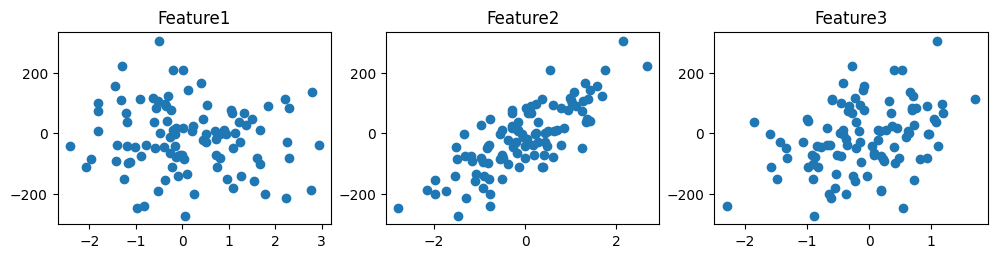

In [38]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(12, 2.5))

ax1.scatter(df['feature1'], df['target'])
ax1.set_title("Feature1")
ax2.scatter(df['feature2'], df['target'])
ax2.set_title("Feature2")
ax3.scatter(df['feature3'], df['target'])
ax3.set_title("Feature3")

plt.show()

### Multicollinearity

In [39]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = []

for i in range(X_train.shape[1]):
    vif.append(variance_inflation_factor(X_train, i))

In [40]:
pd.DataFrame({'vif': vif}, index=df.columns[0:3]).T

,feature1,feature2,feature3
vif,1.00228,1.064729,1.062951


<Axes: >

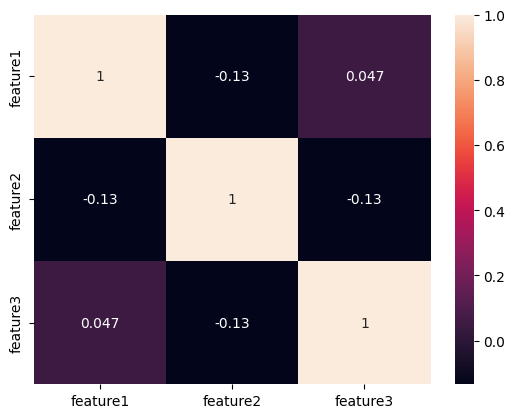

In [41]:
# Another Technique
sns.heatmap(df.iloc[:,0:3].corr(),annot=True)

### Normality of Residual

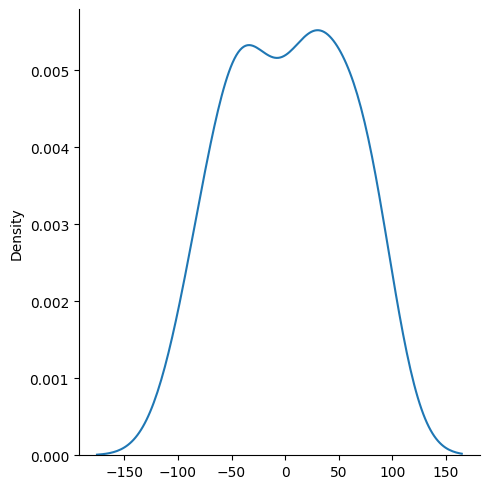

In [42]:
sns.displot(residual,kind='kde')

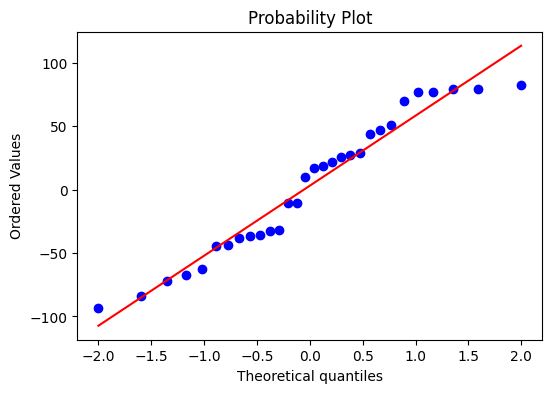

In [43]:
# QQ Plot

import scipy as sp

fig, ax = plt.subplots(figsize=(6,4))
sp.stats.probplot(residual, plot=ax, fit=True)

plt.show()

### Homoscedasticity

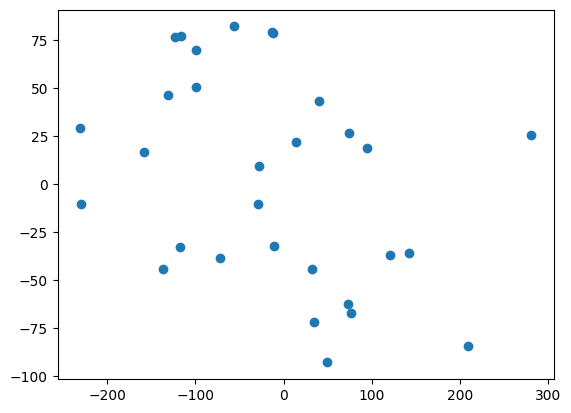

In [44]:
plt.scatter(y_pred,residual)

### Autocorrelation of Residuals

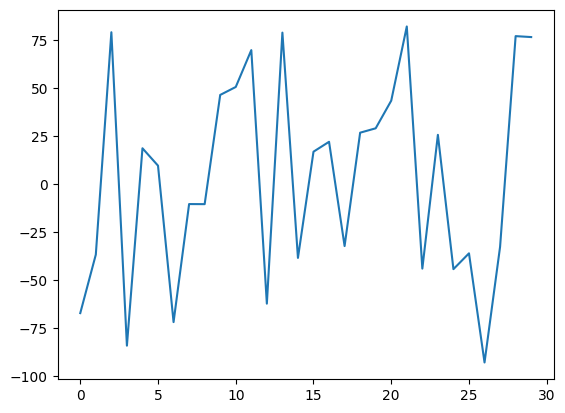

In [45]:
plt.plot(residual)